In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [3]:
model_path = "../models/plant_disease_mobilenetv2.keras"
dataset_path = "../dataset/PlantVillage"
val_path = os.path.join(dataset_path, "val")

model = keras.models.load_model(model_path)

class_names = sorted(os.listdir(val_path))

print("Model berhasil dimuat.")
print("Jumlah kelas:", len(class_names))

for i, class_name in enumerate(class_names):
    print(i, class_name)

Model berhasil dimuat.
Jumlah kelas: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_sp

In [4]:
image_paths = []

for class_name in class_names:
    class_path = os.path.join(val_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(
                os.path.join(class_path, file)
            )

random_index = np.random.randint(len(image_paths))
image_path = image_paths[random_index]

print("Jumlah gambar validation:", len(image_paths))
print("Gambar yang dipilih:")
print(image_path)

Jumlah gambar validation: 10861
Gambar yang dipilih:
../dataset/PlantVillage\val\Grape___Black_rot\2826340e-dbd6-4e2c-b097-2b0dcec8ab77___FAM_B.Rot 0420.JPG


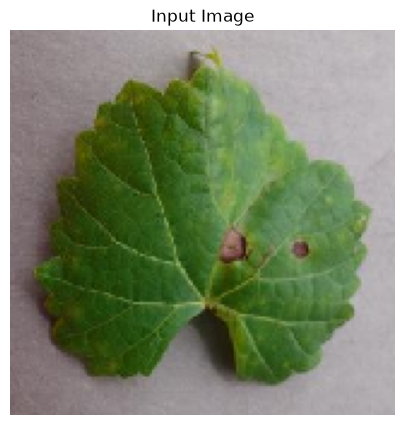

In [5]:
image = tf.keras.utils.load_img(
    image_path,
    target_size=(160, 160)
)

image_array = tf.keras.utils.img_to_array(image)

plt.figure(figsize=(5, 5))
plt.imshow(image_array.astype("uint8"))
plt.axis("off")
plt.title("Input Image")
plt.show()

In [6]:
input_image = np.expand_dims(image_array, axis=0)

prediction = model.predict(input_image, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

actual_class = os.path.basename(os.path.dirname(image_path))

print("Actual class    :", actual_class)
print("Predicted class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")

Actual class    : Grape___Black_rot
Predicted class : Grape___Black_rot
Confidence      : 96.94%


In [7]:
top_5_indices = np.argsort(prediction[0])[-5:][::-1]

print("Top 5 Predictions:\n")

for rank, index in enumerate(top_5_indices, start=1):
    class_name = class_names[index]
    probability = prediction[0][index] * 100

    print(f"{rank}. {class_name}")
    print(f"   Confidence: {probability:.2f}%")

Top 5 Predictions:

1. Grape___Black_rot
   Confidence: 96.94%
2. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
   Confidence: 1.67%
3. Apple___Apple_scab
   Confidence: 0.54%
4. Grape___healthy
   Confidence: 0.51%
5. Apple___Cedar_apple_rust
   Confidence: 0.14%


In [ ]:
def predict_image(image_path):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(160, 160)
    )

    image_array = tf.keras.utils.img_to_array(image)
    input_image = np.expand_dims(image_array, axis=0)

    prediction = model.predict(input_image, verbose=0)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    return predicted_class, confidence

print("Fungsi prediction berhasil dibuat.")

Fungsi prediction berhasil dibuat.


In [10]:
predicted_class, confidence = predict_image(image_path)

print("Prediction :", predicted_class)
print(f"Confidence : {confidence:.2f}%")

Prediction : Grape___Black_rot
Confidence : 96.94%


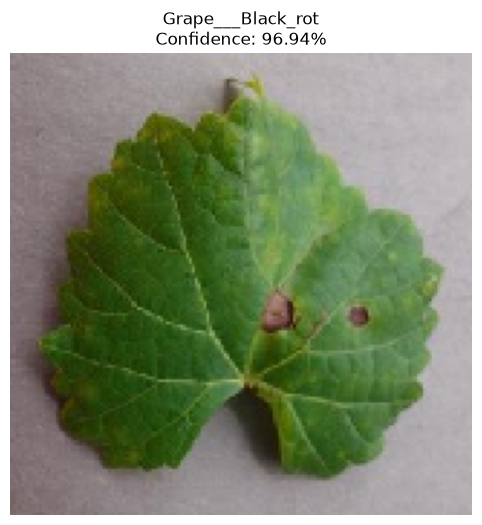

In [11]:
plt.figure(figsize=(6, 6))

image = tf.keras.utils.load_img(
    image_path,
    target_size=(160, 160)
)

plt.imshow(image)
plt.axis("off")
plt.title(
    f"{predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

In [12]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Jumlah label   :", len(y_true))
print("Jumlah prediksi:", len(y_pred))
print("Prediksi benar :", np.sum(y_true == y_pred))
print("Prediksi salah :", np.sum(y_true != y_pred))

NameError: name 'val_ds' is not defined